**Complete pipeline: load → normalize → train → evaluate → export debate payloads**

Input : `patient_cards_v4.json`  
Output: `best_model.pt`, `debate_inputs.json`, `test_predictions.csv`, `model_config.json`

In [ ]:
!pip install -q scikit-learn joblib

from google.colab import drive
drive.mount('/content/drive')

import importlib
for pkg in ['torch', 'numpy', 'sklearn']:
    print(f'  {pkg:<12} {importlib.import_module(pkg).__version__}')
print('Ready ✓')

Mounted at /content/drive
  torch        2.10.0+cu128
  numpy        2.0.2
  sklearn      1.6.1
Ready ✓


## configuration

In [ ]:
import os, torch

# ── EDIT THESE ───────────────────────────────────────────────────────────────
CARDS_PATH  = '/content/drive/MyDrive/702 project/patient_cards_v6_grouped.json'
OUTPUT_DIR  = '/content/drive/MyDrive/702 project/TOP5_lstm_outputs'   # new output dir for improved model

# Model
HIDDEN_DIM   = 256    # bidirectional → effective 512
NUM_LAYERS   = 2      # 2 layers is sufficient for 12 timesteps
DROPOUT      = 0.4    # increased from 0.3 to reduce overfitting
NUM_HEADS    = 4      # attention heads

# Training
BATCH_SIZE   = 64     # larger batches for more stable gradients
EPOCHS       = 80     # more epochs with longer patience
LR           = 1e-3   # higher initial LR (scheduler will reduce)
WEIGHT_DECAY = 1e-4   # L2 regularization

# Focal Loss parameters (handles class imbalance better than weighted CE)
FOCAL_ALPHA  = 1.0    # weighting factor
FOCAL_GAMMA  = 2.0    # focusing parameter (higher = more focus on hard examples)

# Split
TRAIN_RATIO  = 0.70
VAL_RATIO    = 0.15

PATIENCE     = 15     # longer patience - F1 macro is noisy
SPLIT_SEED  = 42

TOP_K_DEBATE = 3      # top-K ICD candidates passed to debate agents
# ─────────────────────────────────────────────────────────────────────────────

os.makedirs(OUTPUT_DIR, exist_ok=True)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {device}')
print(f'Output : {OUTPUT_DIR}')

Device : cuda
Output : /content/drive/MyDrive/702 project/TOP5_lstm_outputs


##load patient cards

In [ ]:
import json
import numpy as np

print(f'Loading {CARDS_PATH} …')
with open(CARDS_PATH) as f:
    data = json.load(f)

cards         = data['patients']
label_map     = data['label_map']
feature_names = data['feature_names']
n_features    = data['n_features']
n_timesteps   = data['n_timesteps']
num_classes   = len(label_map)
inv_label_map = {v: k for k, v in label_map.items()}

# Feature columns are interleaved [val_0, mask_0, val_1, mask_1, ...]
val_idx  = list(range(0, n_features, 2))
mask_idx = list(range(1, n_features, 2))

# Raw variable names (strip the '_val' suffix from value columns)
raw_var_names = [feature_names[i].replace('_val', '') for i in val_idx]

# ── Disambiguate duplicates ───────────────────────────────────────────────────
# MIMIC sometimes records the same physiologic measurement under multiple
# itemids (e.g., sodium from chemistry vs. blood-gas panels). Those land as
# separate columns with the same display name. We keep all the data and just
# uniquify the names with __1 / __2 suffixes.
from collections import defaultdict, Counter

seen_count   = defaultdict(int)
var_names    = []
rename_log   = []

for raw in raw_var_names:
    seen_count[raw] += 1
    if seen_count[raw] == 1:
        # First occurrence — leave as-is for now (might rename in pass 2 if it dups)
        var_names.append(raw)
    else:
        suffixed = f'{raw}__{seen_count[raw]}'
        var_names.append(suffixed)
        rename_log.append((raw, suffixed))

# Pass 2: any name that ended up duplicated (was seen 2+ times) — also suffix
# its FIRST occurrence to make ordering consistent (foo, foo__2, foo__3 → foo__1, foo__2, foo__3).
final_counts = Counter(raw_var_names)
needs_first_rename = {name for name, c in final_counts.items() if c > 1}
if needs_first_rename:
    first_seen_at = {}
    for i, name in enumerate(raw_var_names):
        if name in needs_first_rename and name not in first_seen_at:
            first_seen_at[name] = i
            var_names[i] = f'{name}__1'
            rename_log.append((name, f'{name}__1'))

# Final sanity: every name unique
assert len(set(var_names)) == len(var_names), \
    f'Still duplicated: {[n for n, c in Counter(var_names).items() if c > 1]}'

n_vars = len(var_names)

if rename_log:
    print(f'\nDisambiguated {len({orig for orig, _ in rename_log})} duplicate names:')
    by_orig = defaultdict(list)
    for orig, new in rename_log:
        by_orig[orig].append(new)
    for orig, news in sorted(by_orig.items()):
        print(f'  {orig!r:<30} → {sorted(set(news))}')
else:
    print('\nNo duplicates in feature names — nothing to rename.')

# Sanity check on data shape (unchanged from before)
c0  = cards[0]
ts0 = np.array(c0['time_series'])
assert ts0.shape == (n_timesteps, n_features), f'Shape mismatch: {ts0.shape}'
assert isinstance(c0['label'], int)
assert np.isfinite(ts0).all(), 'NaN/Inf in time_series'

print(f'\nCards     : {len(cards):,}')
print(f'Classes   : {num_classes}')
print(f'Tensor    : ({n_timesteps}, {n_features}) per patient')
print(f'Variables : {n_vars} (each with value + mask channel)')

TOP_5_CLASSES = ['SEPSIS', 'STROKE_NEURO', 'ACUTE_MI',
                 'CORONARY_ARTERY_DZ', 'HEART_FAILURE']

# Filter
keep_label_ids = {label_map[c] for c in TOP_5_CLASSES}
cards = [c for c in cards if c['label'] in keep_label_ids]

# Remap labels to 0..4
old_to_new = {old: new for new, old in enumerate(sorted(keep_label_ids))}
new_label_map = {inv_label_map[old]: new for old, new in old_to_new.items()}
new_inv_label_map = {v: k for k, v in new_label_map.items()}

for c in cards:
    c['label'] = old_to_new[c['label']]

num_classes = 5
label_map = new_label_map
inv_label_map = new_inv_label_map

Loading /content/drive/MyDrive/702 project/patient_cards_v6_grouped.json …

Disambiguated 4 duplicate names:
  'anion_gap'                    → ['anion_gap__1', 'anion_gap__2']
  'chloride'                     → ['chloride__1', 'chloride__2']
  'hemoglobin'                   → ['hemoglobin__1', 'hemoglobin__2']
  'sodium'                       → ['sodium__1', 'sodium__2']

Cards     : 28,467
Classes   : 21
Tensor    : (12, 136) per patient
Variables : 68 (each with value + mask channel)


In [ ]:
from collections import Counter

# ── Step 1: compute class frequencies ─────────────────────────────────────────
label_counts = Counter(c['label'] for c in cards)

# Top-5 most common label IDs
top5_label_ids = [label for label, _ in label_counts.most_common(5)]

# Convert to label names (for readability)
top5_label_names = [inv_label_map[l] for l in top5_label_ids]

print("\nTop 5 classes by frequency:")
for i, (lid, count) in enumerate(label_counts.most_common(5)):
    print(f"  {i}: {inv_label_map[lid]} (id={lid}) → {count:,} cards")

# ── Step 2: filter cards ──────────────────────────────────────────────────────
cards = [c for c in cards if c['label'] in top5_label_ids]

# ── Step 3: remap labels to 0..4 (preserve frequency order) ───────────────────
old_to_new = {old: new for new, old in enumerate(top5_label_ids)}

new_label_map = {inv_label_map[old]: new for old, new in old_to_new.items()}
new_inv_label_map = {v: k for k, v in new_label_map.items()}

for c in cards:
    c['label'] = old_to_new[c['label']]

num_classes = 5
label_map = new_label_map
inv_label_map = new_inv_label_map

# ── Step 4: print counts AFTER filtering/remapping ────────────────────────────
new_counts = Counter(c['label'] for c in cards)

print("\nCounts after filtering + remapping:")
for new_id in range(5):
    print(f"  {new_id}: {inv_label_map[new_id]} → {new_counts[new_id]:,} cards")



Top 5 classes by frequency:
  0: SEPSIS (id=3) → 5,524 cards
  1: STROKE_NEURO (id=4) → 4,740 cards
  2: ACUTE_MI (id=0) → 2,361 cards
  3: CORONARY_ARTERY_DZ (id=1) → 2,335 cards
  4: HEART_FAILURE (id=2) → 1,794 cards

Counts after filtering + remapping:
  0: SEPSIS → 5,524 cards
  1: STROKE_NEURO → 4,740 cards
  2: ACUTE_MI → 2,361 cards
  3: CORONARY_ARTERY_DZ → 2,335 cards
  4: HEART_FAILURE → 1,794 cards


## patient-level train/val/test split

In [ ]:
import random
from collections import defaultdict, Counter

random.seed(SPLIT_SEED)
np.random.seed(SPLIT_SEED)

# Group by patient_id so the same patient never spans train + test
patient_to_cards = defaultdict(list)
cards = sorted(cards, key=lambda x: x['patient_id'])

for i, card in enumerate(cards):
    patient_to_cards[card['patient_id']].append(i)

patient_ids = list(patient_to_cards.keys())
random.shuffle(patient_ids)

n_train = int(len(patient_ids) * TRAIN_RATIO)
n_val   = int(len(patient_ids) * VAL_RATIO)

train_pids = patient_ids[:n_train]
val_pids   = patient_ids[n_train:n_train + n_val]
test_pids  = patient_ids[n_train + n_val:]

train_cards = [cards[i] for pid in train_pids for i in patient_to_cards[pid]]
val_cards   = [cards[i] for pid in val_pids   for i in patient_to_cards[pid]]
test_cards  = [cards[i] for pid in test_pids  for i in patient_to_cards[pid]]

print(f'Patients — train: {len(train_pids):,}  val: {len(val_pids):,}  test: {len(test_pids):,}')
print(f'Stays    — train: {len(train_cards):,}  val: {len(val_cards):,}  test: {len(test_cards):,}')

# Label distribution
train_counts = Counter(c['label'] for c in train_cards)
rarest  = min(train_counts, key=train_counts.get)
richest = max(train_counts, key=train_counts.get)
print(f'\nLabel imbalance — most: {inv_label_map[richest]} n={train_counts[richest]}  '
      f'rarest: {inv_label_map[rarest]} n={train_counts[rarest]}  '
      f'ratio: {train_counts[richest]/max(train_counts[rarest],1):.1f}x')

import hashlib
test_signature = hashlib.md5(
    ','.join(str(c['patient_id']) + ':' + str(c.get('stay_id', '')) for c in test_cards).encode()
).hexdigest()
print(f'\nTest cohort signature: {test_signature}')
print('  (should match between LSTM and LightGBM runs to validate fair comparison)')

Patients — train: 9,624  val: 2,062  test: 2,063
Stays    — train: 11,716  val: 2,554  test: 2,484

Label imbalance — most: SEPSIS n=3839  rarest: HEART_FAILURE n=1268  ratio: 3.0x

Test cohort signature: cecc29fd0d5283d8b86fb5be8fc250c5
  (should match between LSTM and LightGBM runs to validate fair comparison)


## feature normalization
Fit `StandardScaler` on training **value columns only** (even indices).  
Mask columns (odd indices, always 0/1) are left untouched.  
Scaler is saved to disk so the debate framework notebook can apply it at inference.

In [ ]:
# ── Feature scale diagnostic BEFORE normalisation ────────────────────────
X_raw = np.array([c['time_series'] for c in train_cards])  # (N, 12, F)

val_idx  = list(range(0, n_features, 2))   # even = value columns
mask_idx = list(range(1, n_features, 2))   # odd  = mask columns

print(f'Top-20 feature scales (observed values only):')
print(f"{'feature':<40} {'mean':>8} {'std':>8} {'max':>8}")
print('-' * 68)
for idx, fi in enumerate(val_idx[:20]):
    col   = X_raw[:, :, fi].flatten()
    obs   = col[col != 0]
    if len(obs) > 0:
        fname = feature_names[fi].replace('_val', '')
        print(f'  {fname:<38} {obs.mean():>8.2f} {obs.std():>8.2f} {obs.max():>8.2f}')

Top-20 feature scales (observed values only):
feature                                      mean      std      max
--------------------------------------------------------------------
  heart_rate                                83.77    39.19  7567.00
  respiratory_rate                          19.92     5.89   228.00
  o2_saturation_pulseoxymetry              231.57 35827.64 9900000.00
  non_invasive_blood_pressure_systolic     119.46    21.10   249.00
  non_invasive_blood_pressure_diastolic     68.43   166.42 59112.00
  non_invasive_blood_pressure_mean          82.21    40.05  8321.00
  arterial_blood_pressure_mean              75.83    24.42   883.00
  arterial_blood_pressure_systolic         112.96    25.07   265.00
  arterial_blood_pressure_diastolic         56.44    14.29   262.00
  temperature_fahrenheit                    98.35     5.89  1200.20
  glucose_finger_stick                     150.23    57.46   500.00
  inspired_o2_fraction                      49.92    21.76   100.00

In [ ]:
from sklearn.preprocessing import StandardScaler
import joblib

# Fit on training val columns — shape (N_train * T, F/2)
X_train_raw  = np.array([c['time_series'] for c in train_cards])
N_tr, T, F   = X_train_raw.shape
train_vals   = X_train_raw[:, :, val_idx].reshape(-1, len(val_idx))

scaler = StandardScaler()
scaler.fit(train_vals)

scaler_path = os.path.join(OUTPUT_DIR, 'feature_scaler.pkl')
joblib.dump(scaler, scaler_path)
print(f'Scaler fitted on {N_tr:,} training stays and saved to {scaler_path}')

def normalise(cards_list, scaler, val_idx, mask_idx):
    """
    Apply fitted scaler to val columns only.
    Mask columns (0/1) are preserved exactly as-is.
    Returns float32 numpy array (N, T, F).
    """
    X     = np.array([c['time_series'] for c in cards_list], dtype=np.float32)
    N, T, F = X.shape
    vals_scaled = scaler.transform(
        X[:, :, val_idx].reshape(-1, len(val_idx))
    ).reshape(N, T, len(val_idx)).astype(np.float32)
    X[:, :, val_idx] = vals_scaled
    return X

X_train = normalise(train_cards, scaler, val_idx, mask_idx)
X_val   = normalise(val_cards,   scaler, val_idx, mask_idx)
X_test  = normalise(test_cards,  scaler, val_idx, mask_idx)

print(f'After scaling:')
print(f'  val cols  — mean: {X_train[:,:,val_idx].mean():.4f}  '
                      f'std: {X_train[:,:,val_idx].std():.4f}')
print(f'  mask cols — mean: {X_train[:,:,mask_idx].mean():.4f}  '
                      f'min: {X_train[:,:,mask_idx].min():.0f}  '
                      f'max: {X_train[:,:,mask_idx].max():.0f}')

Scaler fitted on 11,716 training stays and saved to /content/drive/MyDrive/702 project/TOP5_lstm_outputs/feature_scaler.pkl
After scaling:
  val cols  — mean: 0.0000  std: 1.0000
  mask cols — mean: 0.1449  min: 0  max: 1


## dataset and data loader

In [ ]:
from torch.utils.data import Dataset, DataLoader

class ICUDataset(Dataset):
    """Lean dataset — tensors only. clinical_summary accessed separately."""
    def __init__(self, X_norm, cards):
        self.X      = X_norm                              # (N, 12, F) float32
        self.labels = np.array([c['label'] for c in cards], dtype=np.int64)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'time_series': torch.from_numpy(self.X[idx]),          # (12, F)
            'label':       torch.tensor(self.labels[idx], dtype=torch.long),
        }

train_ds = ICUDataset(X_train, train_cards)
val_ds   = ICUDataset(X_val,   val_cards)
test_ds  = ICUDataset(X_test,  test_cards)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=(device=='cuda'))
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=(device=='cuda'))
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=(device=='cuda'))

# Verify one batch
batch = next(iter(train_loader))
print(f'Batch time_series : {batch["time_series"].shape}  dtype={batch["time_series"].dtype}')
print(f'Batch label       : {batch["label"].shape}  dtype={batch["label"].dtype}')

Batch time_series : torch.Size([64, 12, 136])  dtype=torch.float32
Batch label       : torch.Size([64])  dtype=torch.int64


## model

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ══════════════════════════════════════════════════════════════════════════════
# FOCAL LOSS - handles class imbalance better than weighted cross-entropy
# ══════════════════════════════════════════════════════════════════════════════
class FocalLoss(nn.Module):
    """
    Focal Loss: down-weights easy examples, focuses on hard ones.
    Particularly effective for imbalanced classification.

    FL(p_t) = -alpha * (1 - p_t)^gamma * log(p_t)
    """
    def __init__(self, alpha=1.0, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)  # probability of correct class
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss

# ══════════════════════════════════════════════════════════════════════════════
# LSTM WITH TEMPORAL ATTENTION
# ══════════════════════════════════════════════════════════════════════════════
class LSTMWithAttention(nn.Module):
    """
    Bidirectional LSTM with multi-head self-attention over timesteps.

    The attention mechanism allows the model to focus on the most clinically
    relevant timesteps (e.g., sudden deterioration, critical events) rather
    than treating all 12 hours equally.
    """
    def __init__(self, input_dim, hidden_dim, num_layers, num_classes,
                 dropout=0.3, num_heads=4):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # Bidirectional LSTM
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True
        )

        # Multi-head self-attention over timesteps
        self.attention = nn.MultiheadAttention(
            embed_dim=hidden_dim * 2,  # bidirectional
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        # Layer norm for attention output
        self.layer_norm = nn.LayerNorm(hidden_dim * 2)

        # Classification head with intermediate layer
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_dim * 2, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, num_classes)

        # Store attention weights for interpretability
        self.last_attn_weights = None

    def forward(self, x, return_attention=False):
        # x: (batch, seq_len, input_dim)
        batch_size = x.size(0)

        # LSTM encoding
        lstm_out, _ = self.lstm(x)  # (batch, seq_len, hidden_dim * 2)

        # Self-attention over timesteps
        # Query, Key, Value are all the LSTM outputs
        attn_out, attn_weights = self.attention(
            lstm_out, lstm_out, lstm_out,
            need_weights=True
        )
        self.last_attn_weights = attn_weights.detach()  # store for analysis

        # Residual connection + layer norm
        attn_out = self.layer_norm(lstm_out + attn_out)

        # Global average pooling over timesteps
        pooled = attn_out.mean(dim=1)  # (batch, hidden_dim * 2)

        # Classification
        out = self.dropout(pooled)
        out = F.relu(self.fc1(out))
        out = self.dropout(out)
        logits = self.fc2(out)

        if return_attention:
            return logits, attn_weights
        return logits

# ══════════════════════════════════════════════════════════════════════════════
# INSTANTIATE MODEL AND LOSS
# ══════════════════════════════════════════════════════════════════════════════
model = LSTMWithAttention(
    input_dim=n_features,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    num_classes=num_classes,
    dropout=DROPOUT,
    num_heads=NUM_HEADS
).to(device)

# Focal loss for imbalanced classification
loss_fn = FocalLoss(alpha=FOCAL_ALPHA, gamma=FOCAL_GAMMA)

# Model summary
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model: LSTMWithAttention')
print(f'  Input dim     : {n_features}')
print(f'  Hidden dim    : {HIDDEN_DIM} (effective: {HIDDEN_DIM * 2} bidirectional)')
print(f'  Num layers    : {NUM_LAYERS}')
print(f'  Attention     : {NUM_HEADS} heads')
print(f'  Num classes   : {num_classes}')
print(f'  Total params  : {total_params:,}')
print(f'  Trainable     : {trainable_params:,}')
print(f'Loss: FocalLoss(alpha={FOCAL_ALPHA}, gamma={FOCAL_GAMMA})')

Model: LSTMWithAttention
  Input dim     : 136
  Hidden dim    : 256 (effective: 512 bidirectional)
  Num layers    : 2
  Attention     : 4 heads
  Num classes   : 5
  Total params  : 3,568,133
  Trainable     : 3,568,133
Loss: FocalLoss(alpha=1.0, gamma=2.0)


##TRAINing




In [ ]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from sklearn.metrics import f1_score

# AdamW with decoupled weight decay (better than Adam for regularization)
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Cosine annealing with warm restarts - helps escape local minima
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=1e-6)

best_val_f1    = 0.0
best_epoch     = 0
epochs_no_imp  = 0
history        = []

model_path = os.path.join(OUTPUT_DIR, 'best_model.pt')

print(f'Training for up to {EPOCHS} epochs with patience={PATIENCE}')
print(f'Optimizer: AdamW(lr={LR}, weight_decay={WEIGHT_DECAY})')
print(f'Scheduler: CosineAnnealingWarmRestarts(T_0=10, T_mult=2)')
print('=' * 60)

for epoch in range(1, EPOCHS + 1):

    # ── Train ─────────────────────────────────────────────────────────────
    model.train()
    train_loss = 0.0
    for batch in train_loader:
        ts     = batch['time_series'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        logits = model(ts)
        loss   = loss_fn(logits, labels)
        loss.backward()

        # Gradient clipping
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()

    scheduler.step()
    avg_train_loss = train_loss / len(train_loader)
    current_lr = optimizer.param_groups[0]['lr']

    # ── Validate ──────────────────────────────────────────────────────────
    model.eval()
    val_preds, val_labels_list = [], []
    with torch.no_grad():
        for batch in val_loader:
            ts     = batch['time_series'].to(device)
            labels = batch['label'].to(device)
            logits = model(ts)
            val_preds.extend(logits.argmax(-1).cpu().numpy())
            val_labels_list.extend(labels.cpu().numpy())

    val_f1  = f1_score(val_labels_list, val_preds,
                       average='macro', zero_division=0)
    val_acc = np.mean(np.array(val_preds) == np.array(val_labels_list))

    history.append({
        'epoch': epoch, 'train_loss': avg_train_loss,
        'val_acc': val_acc, 'val_f1': val_f1, 'lr': current_lr
    })

    flag = ''
    if val_f1 > best_val_f1:
        best_val_f1   = val_f1
        best_epoch    = epoch
        epochs_no_imp = 0
        torch.save(model.state_dict(), model_path)
        flag = ' ★ best'
    else:
        epochs_no_imp += 1

    print(f'Epoch {epoch:02d}/{EPOCHS}  '
          f'loss={avg_train_loss:.4f}  '
          f'val_acc={val_acc:.3f}  '
          f'val_f1={val_f1:.3f}  '
          f'lr={current_lr:.2e}{flag}')

    if epochs_no_imp >= PATIENCE:
        print(f'\nEarly stopping — no improvement for {PATIENCE} epochs.')
        break

print(f'\n{"═" * 60}')
print(f'Best val F1 = {best_val_f1:.4f} at epoch {best_epoch}')
model.load_state_dict(torch.load(model_path, map_location=device))
print('Best model loaded ✓')

Training for up to 80 epochs with patience=15
Optimizer: AdamW(lr=0.001, weight_decay=0.0001)
Scheduler: CosineAnnealingWarmRestarts(T_0=10, T_mult=2)
Epoch 01/80  loss=0.5840  val_acc=0.647  val_f1=0.507  lr=9.76e-04 ★ best
Epoch 02/80  loss=0.4703  val_acc=0.664  val_f1=0.573  lr=9.05e-04 ★ best
Epoch 03/80  loss=0.4314  val_acc=0.673  val_f1=0.590  lr=7.94e-04 ★ best
Epoch 04/80  loss=0.4050  val_acc=0.686  val_f1=0.611  lr=6.55e-04 ★ best
Epoch 05/80  loss=0.3769  val_acc=0.691  val_f1=0.612  lr=5.01e-04 ★ best
Epoch 06/80  loss=0.3378  val_acc=0.688  val_f1=0.623  lr=3.46e-04 ★ best
Epoch 07/80  loss=0.3069  val_acc=0.685  val_f1=0.608  lr=2.07e-04
Epoch 08/80  loss=0.2781  val_acc=0.692  val_f1=0.615  lr=9.64e-05
Epoch 09/80  loss=0.2430  val_acc=0.686  val_f1=0.617  lr=2.54e-05
Epoch 10/80  loss=0.2251  val_acc=0.693  val_f1=0.621  lr=1.00e-03
Epoch 11/80  loss=0.3540  val_acc=0.677  val_f1=0.624  lr=9.94e-04 ★ best
Epoch 12/80  loss=0.3421  val_acc=0.682  val_f1=0.606  lr=9.76e

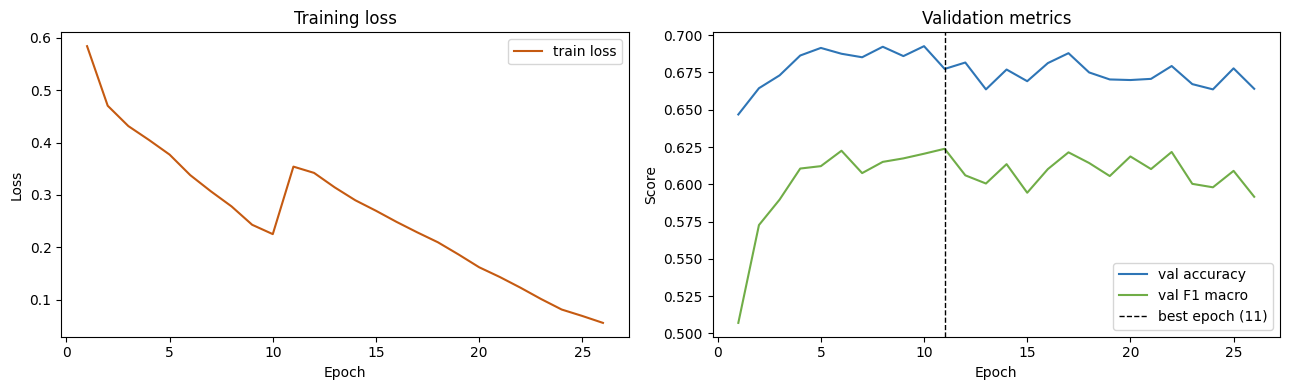

In [ ]:
import matplotlib.pyplot as plt

epochs_run = [h['epoch']      for h in history]
losses     = [h['train_loss'] for h in history]
val_accs   = [h['val_acc']    for h in history]
val_f1s    = [h['val_f1']     for h in history]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(epochs_run, losses, color='#C55A11', label='train loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Training loss')
ax1.legend()

ax2.plot(epochs_run, val_accs, color='#2E75B6', label='val accuracy')
ax2.plot(epochs_run, val_f1s,  color='#70AD47', label='val F1 macro')
ax2.axvline(best_epoch, color='black', linestyle='--',
            linewidth=1, label=f'best epoch ({best_epoch})')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Score')
ax2.set_title('Validation metrics')
ax2.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=150)
plt.show()

## evaluate on test set

In [ ]:
from sklearn.metrics import (accuracy_score, f1_score,
                              classification_report, confusion_matrix)

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for batch in test_loader:
        ts     = batch['time_series'].to(device)
        labels = batch['label'].to(device)
        logits = model(ts)
        probs  = torch.softmax(logits, dim=-1)
        all_preds.extend(logits.argmax(-1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)    # (N_test, num_classes)

# Headline metrics
top1_acc    = accuracy_score(all_labels, all_preds)
f1_macro    = f1_score(all_labels, all_preds, average='macro',    zero_division=0)
f1_weighted = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

# Top-K accuracy
topk_acc = {}
for k in [3, 5]:
    topk_preds  = np.argsort(all_probs, axis=1)[:, -k:]
    topk_acc[k] = np.mean([all_labels[i] in topk_preds[i]
                            for i in range(len(all_labels))])

print('═' * 50)
print('LSTM TEST SET RESULTS')
print('═' * 50)
print(f'  Top-1 accuracy   : {top1_acc*100:6.2f}%')
print(f'  Top-3 accuracy   : {topk_acc[3]*100:6.2f}%')
print(f'  F1 macro         : {f1_macro*100:6.2f}%')
print(f'  F1 weighted      : {f1_weighted*100:6.2f}%')
print(f'  Test samples     : {len(all_labels):,}')

══════════════════════════════════════════════════
LSTM TEST SET RESULTS
══════════════════════════════════════════════════
  Top-1 accuracy   :  67.15%
  Top-3 accuracy   :  93.88%
  F1 macro         :  59.87%
  F1 weighted      :  66.39%
  Test samples     : 2,484


##Extract Top-K Predictions for Debate Agents

Iterates `test_cards` directly (not the DataLoader) so `clinical_summary`
is available per patient without collation issues.

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# EXTRACT TOP-K PREDICTIONS FOR DEBATE AGENTS (FIXED v3)
# ══════════════════════════════════════════════════════════════════════════════
# This version reloads the model to avoid the F variable collision

import torch
import torch.nn as nn
import torch.nn.functional
softmax = torch.nn.functional.softmax  # Explicit reference

# Reload model from disk to get clean state
# (The model in memory has F=136 collision in its forward method)

class LSTMWithAttentionClean(nn.Module):
    """Clean redefinition to avoid F variable collision."""
    def __init__(self, input_dim, hidden_dim, num_layers, num_classes,
                 dropout=0.3, num_heads=4):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True
        )

        self.attention = nn.MultiheadAttention(
            embed_dim=hidden_dim * 2,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        self.layer_norm = nn.LayerNorm(hidden_dim * 2)
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_dim * 2, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, num_classes)
        self.last_attn_weights = None

    def forward(self, x, return_attention=False):
        batch_size = x.size(0)
        lstm_out, _ = self.lstm(x)
        attn_out, attn_weights = self.attention(
            lstm_out, lstm_out, lstm_out, need_weights=True
        )
        self.last_attn_weights = attn_weights.detach()
        attn_out = self.layer_norm(lstm_out + attn_out)
        pooled = attn_out.mean(dim=1)
        out = self.dropout(pooled)
        out = torch.relu(self.fc1(out))  # Use torch.relu explicitly
        out = self.dropout(out)
        logits = self.fc2(out)
        if return_attention:
            return logits, attn_weights
        return logits

# Reinstantiate model with clean class
model_clean = LSTMWithAttentionClean(
    input_dim=n_features,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    num_classes=num_classes,
    dropout=DROPOUT,
    num_heads=NUM_HEADS
).to(device)

# Load the saved weights
model_clean.load_state_dict(torch.load(model_path, map_location=device))
model_clean.eval()
print(f'✓ Model reloaded with clean definition')

# ── Now extract predictions ──────────────────────────────────────────────────
debate_inputs = []
lstm_correct_count = 0
true_in_topk_count = 0

print(f'Extracting top-{TOP_K_DEBATE} predictions for {len(test_cards)} test cases...')

with torch.no_grad():
    for i, card in enumerate(test_cards):
        # Get time series: shape (12, 136)
        X = np.array(card['time_series'], dtype=np.float32)

        # Scale value columns
        X_vals = X[:, val_idx]  # (12, 68)
        X_vals_scaled = scaler.transform(X_vals)
        X[:, val_idx] = X_vals_scaled.astype(np.float32)

        # Get predictions
        X_tensor = torch.from_numpy(X).unsqueeze(0).to(device)
        logits = model_clean(X_tensor)
        probs = softmax(logits, dim=-1).squeeze(0)

        # Top-K
        top_k_idx = probs.argsort(descending=True)[:TOP_K_DEBATE]
        top_k_codes = [inv_label_map[idx.item()] for idx in top_k_idx]
        top_k_probs = [probs[idx].item() for idx in top_k_idx]

        # Ground truth
        true_label = card['label']
        true_code = inv_label_map[true_label]

        # Metrics
        lstm_pred = top_k_codes[0]
        lstm_correct = (lstm_pred == true_code)
        true_in_topk = (true_code in top_k_codes)

        lstm_correct_count += lstm_correct
        true_in_topk_count += true_in_topk

        # Build debate input
        debate_inputs.append({
            'patient_id': card['patient_id'],
            'visit_id': card.get('visit_id', card.get('hadm_id')),
            'stay_id': card['stay_id'],
            'true_label': true_label,
            'true_icd_code': true_code,
            'top_k_codes': top_k_codes,
            'top_k_probs': top_k_probs,
            'lstm_prediction': lstm_pred,
            'lstm_confidence': top_k_probs[0],
            'lstm_correct': lstm_correct,
            'true_in_topk': true_in_topk,
            'clinical_summary': card.get('clinical_summary', {})
        })

        if (i + 1) % 500 == 0:
            print(f'  Processed {i+1}/{len(test_cards)}...')

# Compute aggregate metrics
lstm_top1 = lstm_correct_count / len(test_cards)
in_topk = true_in_topk_count / len(test_cards)

print(f'\n{"═" * 50}')
print(f'DEBATE INPUT EXTRACTION COMPLETE')
print(f'{"═" * 50}')
print(f'  Test cases       : {len(debate_inputs):,}')
print(f'  LSTM Top-1 acc   : {lstm_top1*100:.2f}%')
print(f'  True in Top-{TOP_K_DEBATE}    : {in_topk*100:.2f}%')

✓ Model reloaded with clean definition
Extracting top-3 predictions for 2484 test cases...
  Processed 500/2484...
  Processed 1000/2484...
  Processed 1500/2484...
  Processed 2000/2484...

══════════════════════════════════════════════════
DEBATE INPUT EXTRACTION COMPLETE
══════════════════════════════════════════════════
  Test cases       : 2,484
  LSTM Top-1 acc   : 67.15%
  True in Top-3    : 93.88%


## save all outputs

In [ ]:
import json
import pandas as pd

def to_python(obj):
    """Recursively convert numpy/torch types to plain Python for JSON."""
    if isinstance(obj, (np.integer,)):          return int(obj)
    if isinstance(obj, (np.floating,)):         return float(obj)
    if isinstance(obj, np.ndarray):             return obj.tolist()
    if isinstance(obj, torch.Tensor):           return obj.tolist()
    if isinstance(obj, dict):  return {k: to_python(v) for k, v in obj.items()}
    if isinstance(obj, list):  return [to_python(v) for v in obj]
    return obj

# ── 1. Debate inputs JSON ─────────────────────────────────────────────────
debate_path = os.path.join(OUTPUT_DIR, 'debate_inputs.json')
with open(debate_path, 'w') as f:
    json.dump({
        'label_map':         label_map,
        'inv_label_map':     {str(k): v for k, v in inv_label_map.items()},
        'top_k':             TOP_K_DEBATE,
        'n_test':            len(debate_inputs),
        'lstm_top1_acc':     round(float(lstm_top1), 4),
        'true_in_topk_rate': round(float(in_topk),   4),
        'patients':          to_python(debate_inputs),
    }, f, indent=2)

# ── 2. Test predictions CSV ───────────────────────────────────────────────
csv_path = os.path.join(OUTPUT_DIR, 'test_predictions.csv')
pd.DataFrame([{
    'visit_id':     d['visit_id'],
    'stay_id':      d['stay_id'],
    'true_icd':     d['true_icd_code'],
    'pred_icd':     d['lstm_prediction'],
    'confidence':   d['lstm_confidence'],
    'correct':      d['lstm_correct'],
    'true_in_topk': d['true_in_topk'],
    'top_k_codes':  ' | '.join(d['top_k_codes']),
    'top_k_probs':  ' | '.join(f"{p:.3f}" for p in d['top_k_probs']),
} for d in debate_inputs]).to_csv(csv_path, index=False)

# ── 3. Model config (architecture params for reloading) ───────────────────
config_path = os.path.join(OUTPUT_DIR, 'model_config.json')
with open(config_path, 'w') as f:
    json.dump({
        'model_type':     'LSTMWithAttention',
        'input_dim':      n_features,
        'hidden_dim':     HIDDEN_DIM,
        'num_layers':     NUM_LAYERS,
        'num_classes':    num_classes,
        'dropout':        DROPOUT,
        'num_heads':      NUM_HEADS,
        'bidirectional':  True,
        'n_timesteps':    n_timesteps,
        'label_map':      label_map,
        'feature_names':  feature_names,
        'focal_alpha':    FOCAL_ALPHA,
        'focal_gamma':    FOCAL_GAMMA,
    }, f, indent=2)

# ── Summary ───────────────────────────────────────────────────────────────
print('Saved outputs:')
for path in [model_path, debate_path, csv_path, config_path, scaler_path]:
    mb = os.path.getsize(path) / 1e6
    print(f'  {os.path.basename(path):<30} {mb:.2f} MB')

print(f'\nDebate agent ceiling (true in top-{TOP_K_DEBATE}): {in_topk*100:.1f}%')
print(f'Best val F1 achieved : {best_val_f1*100:.2f}%  (epoch {best_epoch})')

NameError: name 'os' is not defined

check reload